In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        files=os.path.join(dirname, filename)
        print(files)
        if files == "/kaggle/input/petfinder-pawpularity-score/train/7fc71b8da143721939715b1cfe22122f.jpg":
            break


/kaggle/input/test.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv
/kaggle/input/test.zip
/kaggle/input/train.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/description.md
/kaggle/input/train.zip
/kaggle/input/train/e449bbacd2930d6f6ab4589182a09185.jpg
/kaggle/input/train/cfe66786a9c53db0e6936209291cc67d.jpg
/kaggle/input/train/6cf284fbd74fb0b916f279b8c9486c44.jpg
/kaggle/input/train/916ce20c02cd4ef9225d7dbabde68f1c.jpg
/kaggle/input/train/c3214f7072e168d0a2f9ee6b4ddcd3c1.jpg
/kaggle/input/train/3f4020614e47047260b22d4bdc6980fe.jpg
/kaggle/input/train/faa83ed873a0c3f6601626fc8cd1efee.jpg
/kaggle/input/train/872c3643ef186b382eb2bffc759513ce.jpg
/kaggle/input/train/786d4fdf14a947b073aeb1afe800e960.jpg
/kaggle/input/train/0929ac0c6cc43ac05e51460e788190a8.jpg
/kaggle/input/train/28e97352c4a2d1967aa45c7f7b461a45.jpg
/kaggle/input/train/29bfd9472195065d10c05e591af2dbfc.jpg
/kaggle/input/train/2a9858d89826bc41ac41e0b440f236c0.jpg
/kagg

/tmp/ipykernel_11/3740736525.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data["Pawpularity"])
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Pawpularity', ylabel='Density'>

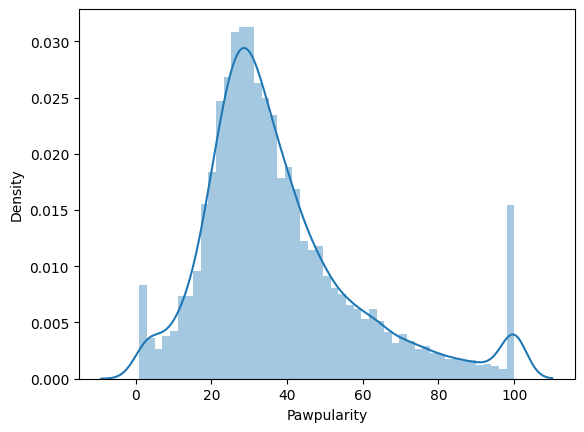

In [2]:
import pandas as pd
import numpy as np
train_data=pd.read_csv("/kaggle/input/petfinder-pawpularity-score/train.csv").sample(frac=1, random_state=0)
test_data=pd.read_csv("/kaggle/input/petfinder-pawpularity-score/test.csv").sample(frac=1, random_state=0)
import seaborn as sns
sns.distplot(train_data["Pawpularity"])


In [3]:
#train_data=train_data[train_data["Pawpularity"] <= 99]
#train_data=train_data[train_data["Pawpularity"] >= 1]
#sns.distplot(train_data["Pawpularity"])


In [4]:
train_data.isnull().all()


Id               False
Subject Focus    False
Eyes             False
Face             False
Near             False
Action           False
Accessory        False
Group            False
Collage          False
Human            False
Occlusion        False
Info             False
Blur             False
Pawpularity      False
dtype: bool

In [5]:
def classification(vals):
    if vals <= 10:
        return 1
    elif 10 < vals <= 20:
        return 2
    elif 20 < vals <= 30:
        return 3
    elif 30 < vals <= 40:
        return 4
    elif 40 < vals <= 50:
        return 5
    elif 50 < vals <= 60:
        return 6
    elif 60 < vals <= 70:
        return 7
    elif 70 < vals <= 80:
        return 8
    elif 80 < vals <= 90:
        return 9
    elif 90 < vals <= 100:
        return 10


In [6]:
train_data["class"]=train_data["Pawpularity"].apply(classification)


In [7]:
train_data


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity,class
1132,b383a8fa9a5a6064169312e92a2910c8,0,0,1,1,0,0,0,0,0,0,0,0,21,3
7145,a4abd72af83f32d3800da5fc5710fa08,0,1,1,1,0,0,0,0,0,0,0,0,26,3
6763,ae55fc6841d93a3c78ce3aaed4e305a3,0,0,0,1,0,0,0,0,0,0,0,0,32,4
8159,56da144f9de748317953d624aa99b545,0,1,1,1,0,0,0,0,0,0,1,0,31,4
4752,e33b1b5bd035da92eafc3095b7251289,0,0,0,1,0,0,0,0,0,0,0,0,37,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4373,2690e4b06227f387117c9b8b743152fa,0,1,1,1,0,1,0,0,0,0,0,0,17,2
7891,1dc083b3c8cb2aecbda7607f9b1959f2,0,1,1,1,0,0,0,0,0,0,0,0,28,3
4859,20ae6f7630cb68dcc51013f428e607a0,0,1,1,1,0,1,0,0,0,0,0,0,45,5
3264,2f4f42ff31319cc0fb3f247b251ec3ed,0,1,1,0,0,0,1,0,0,0,0,0,29,3


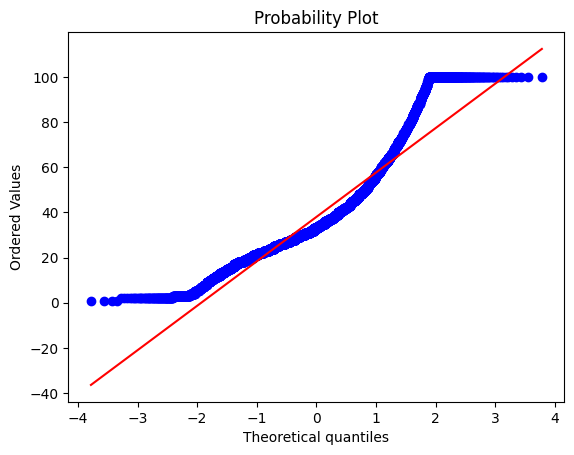

In [8]:
import scipy.stats as stats
import matplotlib.pyplot as plt
stats.probplot(train_data["Pawpularity"], dist="norm", plot=plt)
plt.show()


In [9]:
x_train=np.array(train_data.iloc[:,1:13])
x_test=np.array(test_data.iloc[:,1:])
y_train=np.array(train_data.iloc[:,13])


In [10]:
#from imblearn.over_sampling import RandomOverSampler
#sampler = RandomOverSampler(random_state=42)
#x_train, y_train = sampler.fit_resample(x_train, y_train)


In [11]:
#from imblearn.under_sampling import RandomUnderSampler
#sampler = RandomUnderSampler(random_state=42)
#x_train, y_train = sampler.fit_resample(x_train, y_train)


In [12]:
x_train.shape


(8920, 12)

In [13]:
#StandardScaler is essential for high accuracy.
#from sklearn.preprocessing import StandardScaler
#stdsc = StandardScaler()
#x_train = stdsc.fit_transform(x_train)
#x_test = stdsc.transform(x_test)


In [14]:
from sklearn.model_selection import train_test_split
x_train2, x_valid2, y_train2, y_valid2 = train_test_split(x_train, y_train, test_size=0.1,random_state=123)


In [15]:
import xgboost as xgb
xgbm2 = xgb.XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
                         colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
                         importance_type='gain', interaction_constraints='',
                         learning_rate=0.300000012, max_delta_step=0, max_depth=1,
                         min_child_weight=1, monotone_constraints='()',
                         n_estimators=200, n_jobs=2, num_parallel_tree=1, random_state=0,
                         reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
                         tree_method='exact', validate_parameters=1, verbosity=None)
model1=xgbm2
model1.fit(x_train, y_train)
a1=model1.predict(x_valid2)
p1=model1.predict(x_test)
from sklearn.metrics import mean_squared_error
import numpy as np
w1=np.sqrt(mean_squared_error(a1,y_valid2))
w1


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:00:47] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)


21.589672055858834

<Axes: >

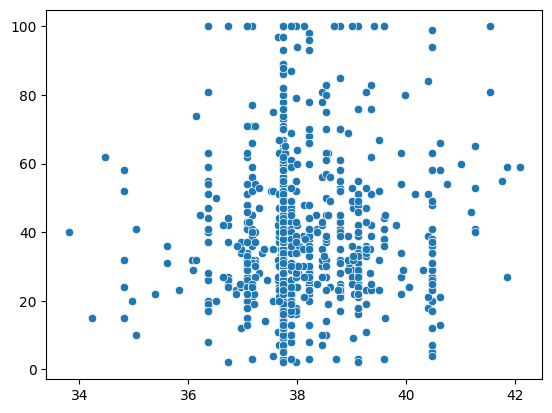

In [16]:
sns.scatterplot(x=a1,y=y_valid2)


In [17]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(random_state=123, max_depth=10,
                               min_samples_leaf=11, n_estimators=200,min_samples_split=2)
model2=forest
model2.fit(x_train, y_train)
a2=model2.predict(x_valid2)
p2=model2.predict(x_test)
w2=np.sqrt(mean_squared_error(a2,y_valid2))
w2


21.427151708030454

<Axes: >

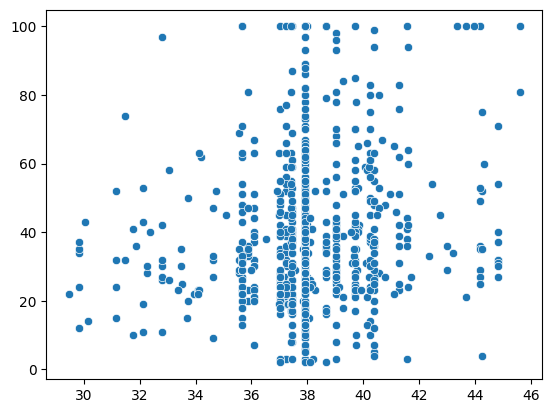

In [18]:
sns.scatterplot(x=a2,y=y_valid2)


In [19]:
#forest.get_params()


In [20]:
import lightgbm as lgb
gbm = lgb.LGBMRegressor()
gbm = lgb.LGBMRegressor(learning_rate=0.0001, max_depth=10, min_child_samples=20,
                        min_child_weight=0.001, num_leaves=31, reg_alpha=0, reg_lambda=1)
model3=gbm
model3.fit(x_train, y_train,verbose=True)
p3 = model3.predict(x_test)
a3= model3.predict(x_valid2)
w3=np.sqrt(mean_squared_error(a3,y_valid2))
w3


TypeError: LGBMRegressor.fit() got an unexpected keyword argument 'verbose'

In [21]:
sns.scatterplot(x=a3,y=y_valid2)


NameError: name 'a3' is not defined

In [22]:
from sklearn.neural_network import MLPRegressor
deep_learning = MLPRegressor(hidden_layer_sizes=(10,10,10,10),random_state=123,verbose=True,activation='relu',
                             early_stopping=True,max_iter=20,
                             solver='adam',warm_start=True)
model4=deep_learning
model4.fit(x_train, y_train)
a4=model4.predict(x_valid2)
p4=model4.predict(x_test)
w4=np.sqrt(mean_squared_error(a4,y_valid2))
w4


Iteration 1, loss = 942.58183571
Validation score: -3.113854
Iteration 2, loss = 913.25434711
Validation score: -2.931421
Iteration 3, loss = 839.93538172
Validation score: -2.362253
Iteration 4, loss = 589.98916788
Validation score: -0.721235
Iteration 5, loss = 266.99655826
Validation score: -0.094839
Iteration 6, loss = 230.16211600
Validation score: -0.076095
Iteration 7, loss = 226.78945671
Validation score: -0.065467
Iteration 8, loss = 224.69391644
Validation score: -0.057754
Iteration 9, loss = 223.05000069
Validation score: -0.052510
Iteration 10, loss = 221.77725226
Validation score: -0.048313
Iteration 11, loss = 220.81198871
Validation score: -0.045886
Iteration 12, loss = 220.01870619
Validation score: -0.042526
Iteration 13, loss = 219.31156523
Validation score: -0.040050
Iteration 14, loss = 218.69953004
Validation score: -0.038949
Iteration 15, loss = 217.98859419
Validation score: -0.035394
Iteration 16, loss = 217.40610089
Validation score: -0.033326
Iteration 17, los

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


21.96195406297458

<Axes: >

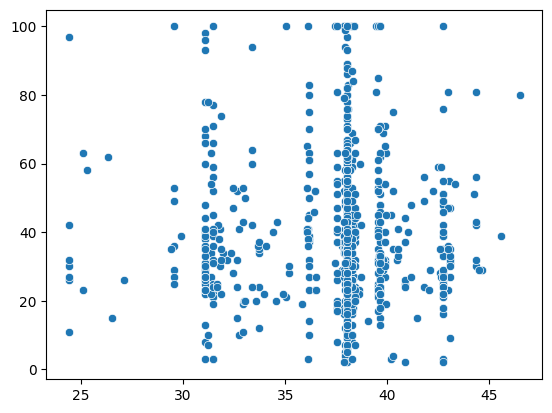

In [23]:
sns.scatterplot(x=a4,y=y_valid2)


In [24]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
model5=lr
l10= model5.fit(x_train, y_train)
a5= model5.predict(x_valid2)
p5= model5.predict(x_test)
w5=np.sqrt(mean_squared_error(a5,y_valid2))
w5


21.588521845851925

<Axes: >

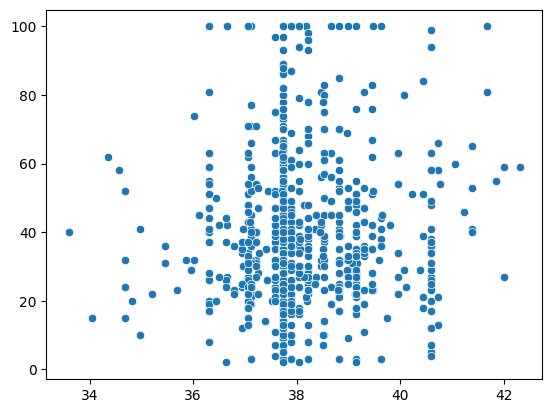

In [25]:
sns.scatterplot(x=a5,y=y_valid2)


In [26]:
from sklearn import tree
dtr = tree.DecisionTreeRegressor()
model6=dtr
dtr = model6.fit(x_train, y_train)
a6= model6.predict(x_valid2)
p6= model6.predict(x_test)
w6=np.sqrt(mean_squared_error(a6,y_valid2))
w6


21.221268375019037

<Axes: >

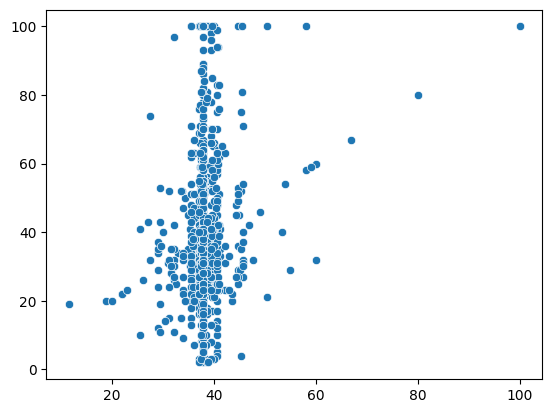

In [27]:
sns.scatterplot(x=a6,y=y_valid2)


In [28]:
from sklearn import svm
from matplotlib import pyplot as plt
svr = svm.SVR(C=1,epsilon=0.1,verbose=True,degree=3)
model7=svr
model7.fit(x_train,y_train)
p7 = model7.predict(x_test)
a7= model7.predict(x_valid2)
w7=np.sqrt(mean_squared_error(a7,y_valid2))
w7


[LibSVM]....
*
optimization finished, #iter = 4589
obj = -130942.303727, rho = -33.185921
nSV = 8853, nBSV = 8814


22.20683345793015

<Axes: >

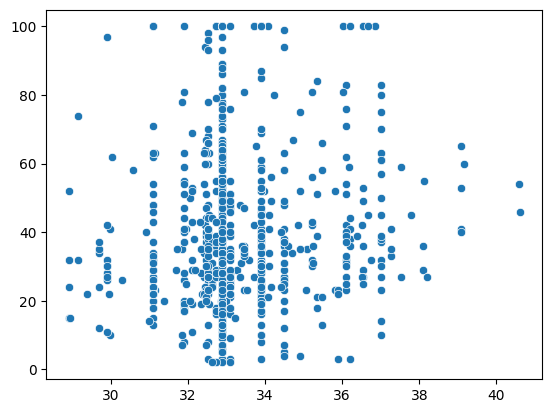

In [29]:
sns.scatterplot(x=a7,y=y_valid2)


In [30]:
### 8.Super Deep Learning
#import tensorflow as tf
#from tensorflow.keras import layers, models
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, Activation,BatchNormalization, Activation,Dropout
#model8 = Sequential()
#model8.add(Dense(10, input_dim=12, activation='relu'))
#model8.add(BatchNormalization())
#model8.add(Dense(10, activation='relu'))
#model8.add(BatchNormalization())
#model8.add(Dense(10, activation='relu'))
#model8.add(BatchNormalization())
#model8.add(Dense(10, activation='relu'))
#model8.add(BatchNormalization())
#model8.add(Dense(1))
#model8.compile(optimizer='adam',loss='mse',metrics=[tf.keras.metrics.RootMeanSquaredError()])
#model8.summary()
#model8.fit(x_train,y_train,batch_size=50, epochs=20)
#p8=model8.predict(x_test)
#a8= model8.predict(x_valid2)
#w8=np.sqrt(mean_squared_error(a8,y_valid2))
#w8
#a8=a8.reshape(-1)
#sns.scatterplot(x=a8,y=y_valid2)


In [31]:
kinds=pd.concat([pd.DataFrame([w1],columns=["XGBoost"],index=["RMSE"]),pd.DataFrame([w2],columns=["R.Forest"],index=["RMSE"]),
                pd.DataFrame([w3],columns=["LightGBM"],index=["RMSE"]),pd.DataFrame([w4],columns=["Neural Net"],index=["RMSE"]),
                pd.DataFrame([w5],columns=["Linear Regressor"],index=["RMSE"]),pd.DataFrame([w6],columns=["Dicision Tree"],index=["RMSE"]),
                pd.DataFrame([w7],columns=["SVR Regressor"],index=["RMSE"])], axis=1).T.sort_values("RMSE")
kinds


NameError: name 'w3' is not defined

In [32]:
p8=np.array([70.23018913764079,47.936271096634556,48.85761357930474,46.358268350017966,41.75953959340538,25.825420084199322,0.7822884587224053,38.75711840766357])


In [33]:
submit_ans=pd.concat([test_data.iloc[:,[0]],pd.DataFrame(p1,columns=["XGBoost"]),pd.DataFrame(p2,columns=["R.Forest"]),
                      pd.DataFrame(p3,columns=["LightGBM"]),pd.DataFrame(p4,columns=["Neural Net"]),
                      pd.DataFrame(p5,columns=["Linear"]),pd.DataFrame(p6,columns=["DTR"]),
                      pd.DataFrame(p7,columns=["SVR"]),pd.DataFrame(p8,columns=["adj"])], axis=1)


NameError: name 'p3' is not defined

In [34]:
submit_ans


NameError: name 'submit_ans' is not defined

In [35]:
final=submit_ans.iloc[:,1:].mean(axis=1)


NameError: name 'submit_ans' is not defined

In [36]:
submit_ans_pd=pd.concat([test_data.iloc[:,[0]],pd.DataFrame(np.round(final,8),columns=["Pawpularity"])], axis=1)
submit_ans_pd


NameError: name 'final' is not defined

In [37]:
submit_ans_pd.to_csv("submission.csv",index=False)
print("File Saved")


NameError: name 'submit_ans_pd' is not defined